In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 1 Code

64
64
64
64
64
64
256
256


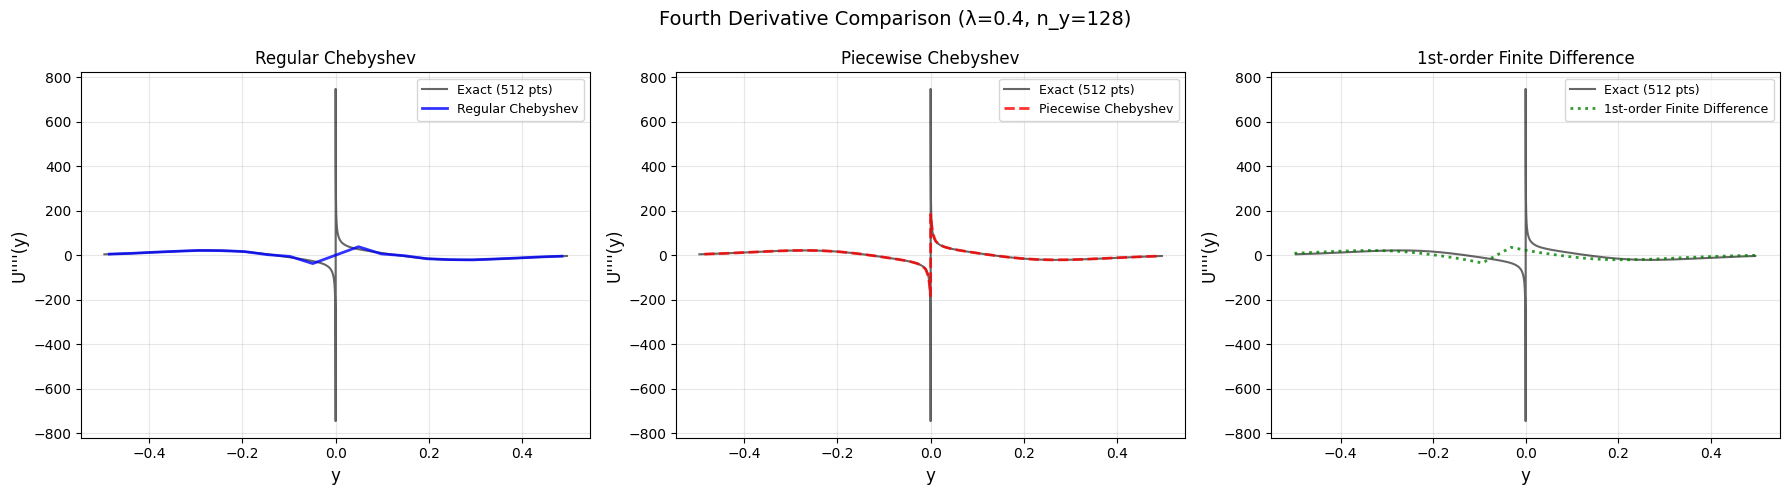

In [5]:
from util.exact_solution import construct_exact_solution
from util.chebyshev_diff import chebyshev_diff_matrix

def finite_diff_1st_order(y, u):
    """
    Compute first derivative using 1st-order accurate finite differences.
    
    The issue with repeated application: forward differences at the left boundary
    compound errors more than backward differences at the right boundary.
    This is because forward differences are less stable when applied repeatedly.
    """
    n = len(y)
    h = y[1] - y[0]  # Assuming uniform spacing
    du = np.zeros(n)
    
    # Forward difference at left boundary (only option): f'(x) ≈ (f(x+h) - f(x)) / h
    du[0] = (u[1] - u[0]) / h
    
    # Forward difference for interior points: f'(x) ≈ (f(x+h) - f(x)) / h
    for i in range(1, n-1):
        du[i] = (u[i+1] - u[i]) / h
    
    # Backward difference at right boundary: f'(x) ≈ (f(x) - f(x-h)) / h
    du[n-1] = (u[n-1] - u[n-2]) / h
    
    return du

n_y = 128
l = 0.4

# ===== Regular Chebyshev on [-2, 2] =====
D_chebyshev, y_chebyshev = chebyshev_diff_matrix(n_y+1, a=-2, b=2)
u_exact_chebyshev = construct_exact_solution(y_chebyshev, l=l)
# Compute fourth derivative: D^4
d4u_chebyshev = D_chebyshev @ D_chebyshev @ D_chebyshev @ D_chebyshev @ u_exact_chebyshev

# ===== Piecewise Chebyshev =====
n_segment = int(n_y/2)+1
D1, y1 = chebyshev_diff_matrix(n_segment, a=-2, b=0)
D2, y2 = chebyshev_diff_matrix(n_segment, a=0, b=2)

y_full = np.concatenate([np.flip(y1), np.flip(y2)])
# Compute exact solution on full grid
u_exact = construct_exact_solution(y_full, l=l)
u_exact_1 = np.flip(u_exact[:n_segment])
u_exact_2 = np.flip(u_exact[n_segment:])

# Compute fourth derivatives: D^4
D4U1 = D1 @ D1 @ D1 @ D1 @ u_exact_1
D4U2 = D2 @ D2 @ D2 @ D2 @ u_exact_2

# Combine for full domain
D4U_full = np.concatenate([np.flip(D4U1), np.flip(D4U2)])

# ===== 1st-order Finite Difference =====
# Use uniform grid for finite differences
y_fd = np.linspace(-2, 2, n_y+1)
u_exact_fd = construct_exact_solution(y_fd, l=l)
# Compute fourth derivative by applying first-order finite difference four times
du1 = finite_diff_1st_order(y_fd, u_exact_fd)
du2 = finite_diff_1st_order(y_fd, du1)
du3 = finite_diff_1st_order(y_fd, du2)
d4u_fd = finite_diff_1st_order(y_fd, du3)

# ===== Exact solution (Piecewise Chebyshev with 512 points) =====
n_y_exact = 512
n_segment_exact = int(n_y_exact/2)+1
D1_exact, y1_exact = chebyshev_diff_matrix(n_segment_exact, a=-2, b=0)
D2_exact, y2_exact = chebyshev_diff_matrix(n_segment_exact, a=0, b=2)

y_full_exact = np.concatenate([np.flip(y1_exact), np.flip(y2_exact)])
u_exact_exact = construct_exact_solution(y_full_exact, l=l)
U1_exact = np.flip(u_exact_exact[:n_segment_exact])
U2_exact = np.flip(u_exact_exact[n_segment_exact:])

D4U1_exact = D1_exact @ D1_exact @ D1_exact @ D1_exact @ U1_exact
D4U2_exact = D2_exact @ D2_exact @ D2_exact @ D2_exact @ U2_exact
D4U_full_exact = np.concatenate([np.flip(D4U1_exact), np.flip(D4U2_exact)])

# Filter exact solution to [-0.5, 0.5]
mask_exact = (y_full_exact >= -0.5) & (y_full_exact <= 0.5)
y_exact_filtered = y_full_exact[mask_exact]
D4U_exact_filtered = D4U_full_exact[mask_exact]

# ===== Filter data to [-0.5, 0.5] range =====
mask_chebyshev = (y_chebyshev >= -0.5) & (y_chebyshev <= 0.5)
y_chebyshev_filtered = y_chebyshev[mask_chebyshev]
d4u_chebyshev_filtered = d4u_chebyshev[mask_chebyshev]

mask_piecewise = (y_full >= -0.5) & (y_full <= 0.5)
y_full_filtered = y_full[mask_piecewise]
D4U_full_filtered = D4U_full[mask_piecewise]

mask_fd = (y_fd >= -0.5) & (y_fd <= 0.5)
y_fd_filtered = y_fd[mask_fd]
d4u_fd_filtered = d4u_fd[mask_fd]

# ===== Plot comparison on separate axes =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Fourth Derivative Comparison (λ={l}, n_y={n_y})', fontsize=14)

# Regular Chebyshev
axes[0].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[0].plot(y_chebyshev_filtered, d4u_chebyshev_filtered, 'b-', linewidth=2, alpha=0.8, label='Regular Chebyshev')
axes[0].set_xlabel('y', fontsize=12)
axes[0].set_ylabel("U''''(y)", fontsize=12)
axes[0].set_title('Regular Chebyshev', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Piecewise Chebyshev
axes[1].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[1].plot(y_full_filtered, D4U_full_filtered, 'r--', linewidth=2, alpha=0.8, label='Piecewise Chebyshev')
axes[1].set_xlabel('y', fontsize=12)
axes[1].set_ylabel("U''''(y)", fontsize=12)
axes[1].set_title('Piecewise Chebyshev', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 1st-order Finite Difference
axes[2].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[2].plot(y_fd_filtered, d4u_fd_filtered, 'g:', linewidth=2, alpha=0.8, label='1st-order Finite Difference')
axes[2].set_xlabel('y', fontsize=12)
axes[2].set_ylabel("U''''(y)", fontsize=12)
axes[2].set_title('1st-order Finite Difference', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Processing λ = 0.4
Level 1/6 (n_y=2): Success=True, Residual norm=0.000000e+00
Level 2/6 (n_y=4): Success=False, Residual norm=4.214685e-08
Level 3/6 (n_y=8): Success=False, Residual norm=1.392587e-07
Level 4/6 (n_y=16): Success=False, Residual norm=5.114785e-07
Level 5/6 (n_y=32): Success=True, Residual norm=1.601628e-06
Level 6/6 (n_y=64): Success=True, Residual norm=7.831559e-06
64
64
Completed λ = 0.4


Processing λ = 0.5
Level 1/6 (n_y=2): Success=True, Residual norm=0.000000e+00
Level 2/6 (n_y=4): Success=True, Residual norm=0.000000e+00
Level 3/6 (n_y=8): Success=False, Residual norm=6.916864e-08
Level 4/6 (n_y=16): Success=False, Residual norm=7.898956e-07
Level 5/6 (n_y=32): Success=True, Residual norm=1.835559e-06
Level 6/6 (n_y=64): Success=False, Residual norm=1.432000e-05
64
64
Completed λ = 0.5



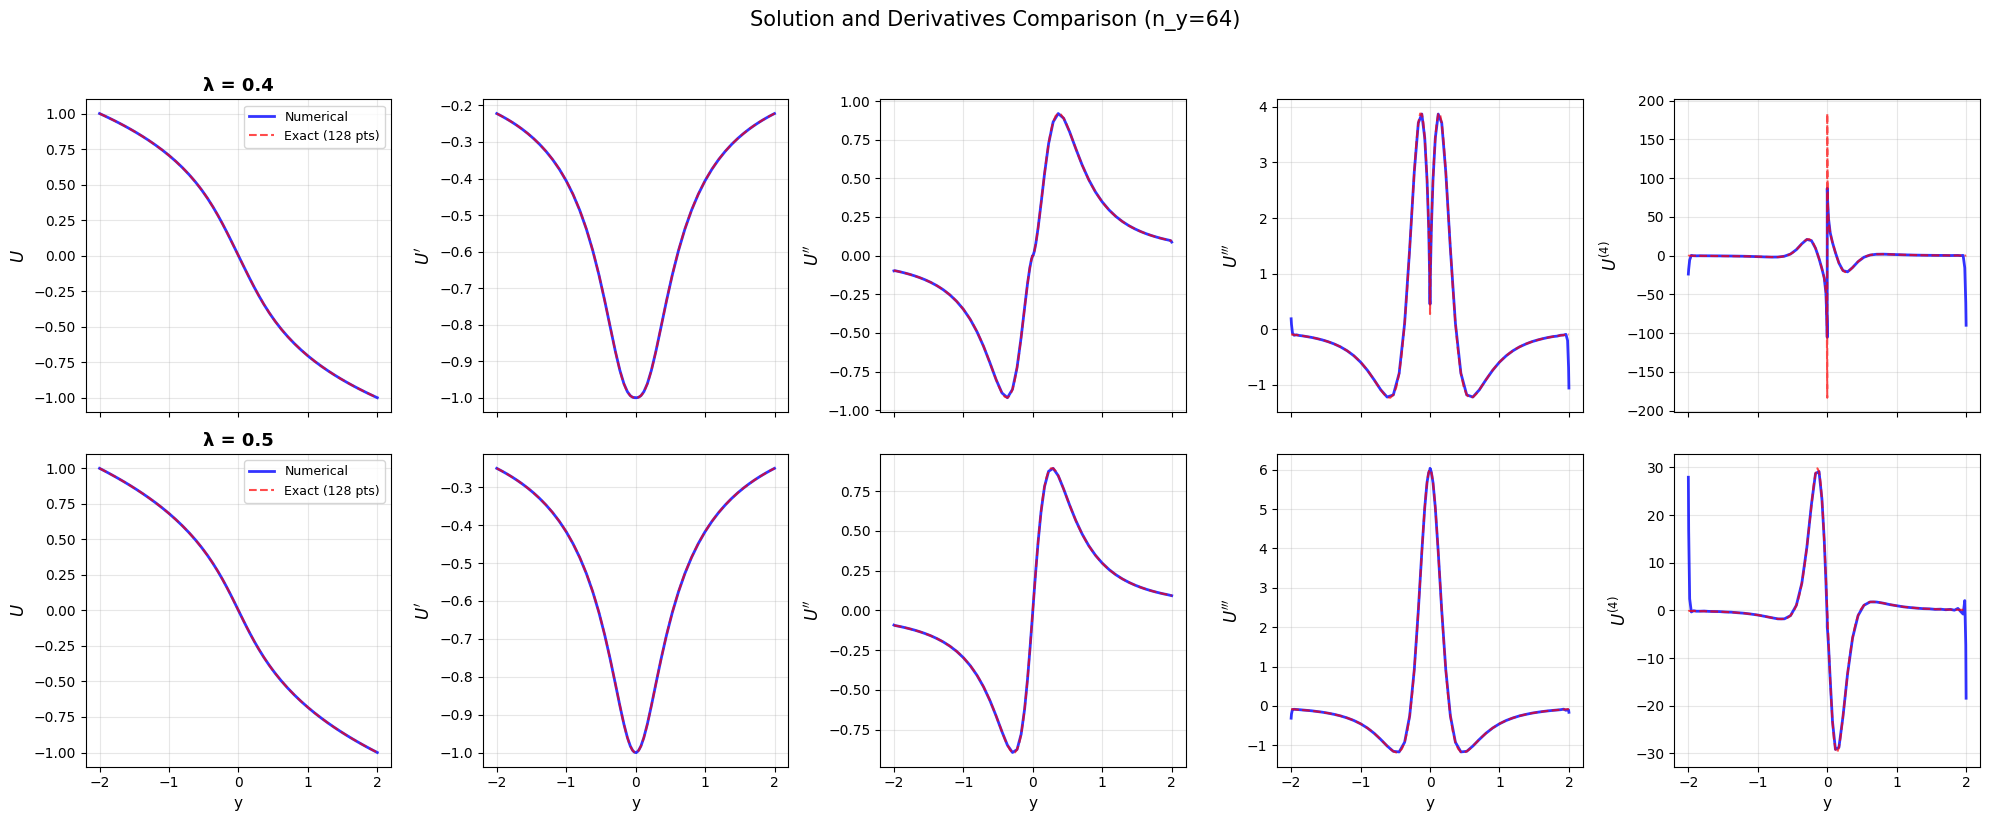

In [20]:
from util.exact_solution import construct_exact_solution
from util.chebyshev_diff import chebyshev_diff_matrix
from chebyshev_piecewise_ad import fixed_l_inference_system

n_y = 64
n_y_exact = 128
lambda_values = [0.4, 0.5]
label_names = ["$U$", "$U'$", "$U''$", "$U'''$", "$U^{(4)}$"]

# Store data for all lambda values
all_data = {}

# Process both lambda values
for l in lambda_values:
    print(f"\n{'='*60}")
    print(f"Processing λ = {l}")
    print(f"{'='*60}")
    
    # ===== Numerical Solution (n_y = 64) =====
    u_num, n_segment, (y1, D1, y2, D2) = fixed_l_inference_system(n_y, l, tol=1e-10, method='hybr')
    
    # Combine full domain
    y_full = np.concatenate([np.flip(y1), np.flip(y2)])
    
    # Extract solution on each segment (flip to match Chebyshev ordering)
    U1 = np.flip(u_num[:n_segment])
    U2 = np.flip(u_num[n_segment:])
    
    # Compute all derivatives for numerical solution
    derivatives_num = [u_num]  # Start with solution itself
    
    U1_current = U1.copy()
    U2_current = U2.copy()
    
    for i in range(4):
        U1_current = D1 @ U1_current
        U2_current = D2 @ U2_current
        derivatives_num.append(np.concatenate([np.flip(U1_current), np.flip(U2_current)]))
    
    # ===== Exact Solution (n_y = 512) =====
    n_segment_exact = int(n_y_exact/2)+1
    D1_exact, y1_exact = chebyshev_diff_matrix(n_segment_exact, a=-2, b=0)
    D2_exact, y2_exact = chebyshev_diff_matrix(n_segment_exact, a=0, b=2)
    
    y_full_exact = np.concatenate([np.flip(y1_exact), np.flip(y2_exact)])
    u_exact_full = construct_exact_solution(y_full_exact, l=l)
    
    # Extract exact solution on each segment (flip to match Chebyshev ordering)
    U1_exact = np.flip(u_exact_full[:n_segment_exact])
    U2_exact = np.flip(u_exact_full[n_segment_exact:])
    
    # Compute all derivatives for exact solution using Chebyshev differentiation
    derivatives_exact = [u_exact_full]  # Start with solution itself
    
    U1_exact_current = U1_exact.copy()
    U2_exact_current = U2_exact.copy()
    
    for i in range(4):
        U1_exact_current = D1_exact @ U1_exact_current
        U2_exact_current = D2_exact @ U2_exact_current
        derivatives_exact.append(np.concatenate([np.flip(U1_exact_current), np.flip(U2_exact_current)]))
    
    # Concatenate segments for continuous plotting
    y_num_full = np.concatenate([np.flip(y1), np.flip(y2)])
    y_exact_full = np.concatenate([np.flip(y1_exact), np.flip(y2_exact)])
    
    # Store data
    all_data[l] = {
        'y_num': y_num_full,
        'y_exact': y_exact_full,
        'derivatives_num': derivatives_num,
        'derivatives_exact': derivatives_exact
    }
    
    print(f"Completed λ = {l}\n")

# ===== Create single figure with 2 rows (one per lambda) and 5 columns (one per derivative) =====
fig, axs = plt.subplots(2, 5, figsize=(20, 8), sharex='col')

for row_idx, l in enumerate(lambda_values):
    data = all_data[l]
    y_num_full = data['y_num']
    y_exact_full = data['y_exact']
    derivatives_num = data['derivatives_num']
    derivatives_exact = data['derivatives_exact']
    
    for col_idx, (arr_num, arr_exact, name) in enumerate(zip(derivatives_num, derivatives_exact, label_names)):
        ax = axs[row_idx, col_idx]
        
        # Plot numerical solution as single continuous line
        ax.plot(y_num_full, arr_num, 'b-', linewidth=2, alpha=0.8, label='Numerical')
        
        # Plot exact solution as single continuous line
        ax.plot(y_exact_full, arr_exact, 'r--', linewidth=1.5, alpha=0.7, label=f'Exact ({n_y_exact} pts)')
        
        ax.set_ylabel(name, fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Add title and legend to first column
        if col_idx == 0:
            ax.set_title(f'λ = {l}', fontsize=13, fontweight='bold')
            ax.legend(fontsize=9)
        
        # Add x-label to bottom row
        if row_idx == 1:
            ax.set_xlabel('y', fontsize=11)

plt.suptitle(f'Solution and Derivatives Comparison (n_y={n_y})', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
# ===== Compute error metrics for exact vs numerical solutions =====
from util.exact_solution import construct_exact_solution

print(f"\n{'='*60}")
print(f"Error Metrics for Solution (n_y={n_y})")
print(f"{'='*60}\n")

for l in lambda_values:
    data = all_data[l]
    y_num_full = data['y_num']
    u_num = data['derivatives_num'][0]  # Solution itself (first element)
    
    # Compute exact solution on the numerical grid for fair comparison
    u_exact_num = construct_exact_solution(y_num_full, l=l)
    
    # Compute difference (error)
    error = u_exact_num - u_num
    
    # Max absolute error
    max_error = np.max(np.abs(error))
    
    # Relative L2 error: ||u_exact - u_num||_2 / ||u_exact||_2
    l2_error = np.linalg.norm(error)
    l2_exact = np.linalg.norm(u_exact_num)
    rel_l2_error = l2_error / l2_exact if l2_exact > 0 else 0
    
    print(f"λ = {l}:")
    print(f"  Max absolute error: {max_error:.2e}")
    print(f"  Relative L2 error:  {rel_l2_error:.2e}")
    print()



Error Metrics for Solution (n_y=64)

32
32
λ = 0.4:
  Max absolute error: 2.06e-07
  Relative L2 error:  1.22e-07

32
32
λ = 0.5:
  Max absolute error: 1.73e-07
  Relative L2 error:  1.08e-07

